# SLayer query-syntax rejections — mini-interact (slayer mode)

**What this is.** In slayer mode the agent answers each task by composing a
**SlayerQuery DSL** payload (`source_model` / `measures` / `dimensions` /
`filters` / `order` / …) and running it through query tools. When that payload is
malformed, SLayer's query layer *rejects* it and the agent must re-author it.
This notebook quantifies that friction across the **latest slayer trajectory per
task**:

1. **Common failure modes** — which DSL mistakes the agent makes.
2. **Retries-to-recovery** — how many attempts it burns before a valid query.
3. **Major contributor to failure?** — whether the friction ever sinks a task.

**Scope.** Headline counts are **DSL-validation rejections only** — errors raised
by SLayer's *query compiler* (the spec is wrong). Three other rejection kinds are
tallied for context but **excluded** from the headline:
`semantic` (valid spec, the *database* rejected it at runtime: `no such
column/table`, generated-SQL `syntax error`), `gate` (`submit_query` refused
because the agent didn't preview the exact query first), and `infra`
(permission-mode denials, schema-drift — harness artefacts, not the agent's
syntax).

All logic lives in `scripts/analyze_query_syntax_rejections.py`; this notebook is
the reproducible human-readable view. Re-run top-to-bottom to refresh against the
current contents of `runs/mini-interact/`.

In [1]:
import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Locate the repo root (the dir holding pyproject.toml) so the notebook works
# regardless of the kernel's CWD.
root = Path.cwd()
while root != root.parent and not (root / "pyproject.toml").exists():
    root = root.parent

spec = importlib.util.spec_from_file_location(
    "aqsr", root / "scripts" / "analyze_query_syntax_rejections.py"
)
aqsr = importlib.util.module_from_spec(spec)
sys.modules["aqsr"] = aqsr
spec.loader.exec_module(aqsr)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

payload = aqsr.build_payload(benchmark="mini-interact", mode="slayer")
agg = payload["aggregate"]
per_task = payload["per_task"]
n = agg["n_tasks"]
bt = agg["bucket_totals"]
print(f"latest slayer trajectories analysed: {n} tasks, "
      f"{agg['total_query_calls']} query-tool calls")
print(f"failed tasks: {agg['n_failed']}/{n}   "
      f"tasks with >=1 DSL rejection: {agg['n_tasks_with_dsl']}/{n}")

latest slayer trajectories analysed: 298 tasks, 4373 query-tool calls
failed tasks: 44/298   tasks with >=1 DSL rejection: 212/298


## Query-tool calls by classification bucket

The split of every query-tool result. Only **`dsl`** feeds the headline; `ok` is
a clean query; the rest are excluded (see scope above).

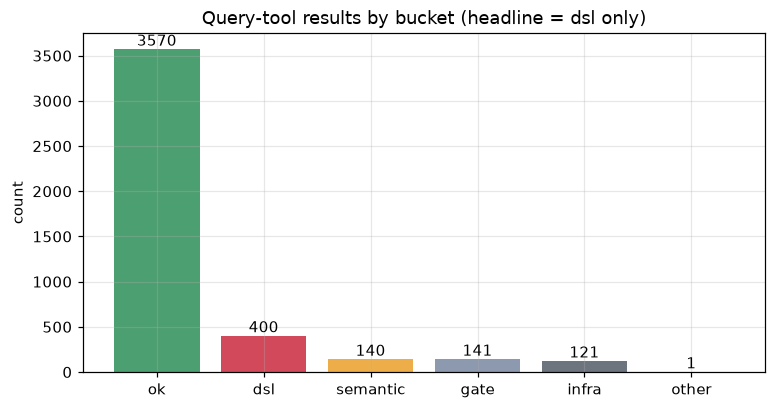

,count,share_%
bucket,,
ok,3570,81.6
dsl,400,9.1
semantic,140,3.2
gate,141,3.2
infra,121,2.8
other,1,0.0


In [2]:
order = ["ok", "dsl", "semantic", "gate", "infra", "other"]
vals = [bt.get(k, 0) for k in order]
colors = ["#4c9f70", "#d1495b", "#edae49", "#8d99ae", "#6c757d", "#adb5bd"]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(order, vals, color=colors)
ax.set_title("Query-tool results by bucket (headline = dsl only)")
ax.set_ylabel("count")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom")
plt.show()

pd.DataFrame({"bucket": order, "count": vals,
              "share_%": [round(100 * v / max(agg['total_query_calls'], 1), 1)
                          for v in vals]}).set_index("bucket")

## Q1 — Common DSL failure modes

Each rejected SlayerQuery is sub-tagged by the *kind* of DSL mistake. This is the
ranked taxonomy of what the agent gets wrong.

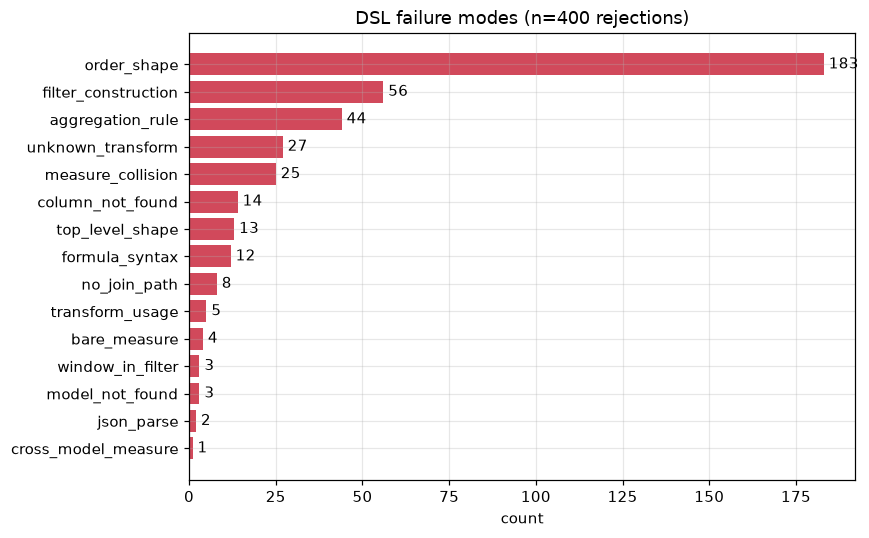

,count,share_pct
sub_tag,,
order_shape,183,45.8
filter_construction,56,14.0
aggregation_rule,44,11.0
unknown_transform,27,6.8
measure_collision,25,6.2
column_not_found,14,3.5
top_level_shape,13,3.2
formula_syntax,12,3.0
no_join_path,8,2.0


In [3]:
sub = agg["dsl_subtag_counts"]
df_modes = (pd.DataFrame({"sub_tag": list(sub), "count": list(sub.values())})
            .assign(share_pct=lambda d: (100 * d["count"] / d["count"].sum()).round(1))
            .sort_values("count", ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_modes["sub_tag"], df_modes["count"], color="#d1495b")
for y, v in enumerate(df_modes["count"]):
    ax.text(v, y, f" {v}", va="center")
ax.set_title(f"DSL failure modes (n={sum(sub.values())} rejections)")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

df_modes.sort_values("count", ascending=False).set_index("sub_tag")

**Reading it.** A handful of mechanical mistakes dominate. `order_shape` —
writing `order` as `{"col": "desc"}` instead of
`{"column": "col", "direction": "desc"}` — is by far the most common, and is a
pure format slip rather than a misunderstanding of the data. The next tier
(`filter_construction`, `aggregation_rule`, `unknown_transform`,
`measure_collision`) are SLayer-DSL idioms the agent has to learn by trial.

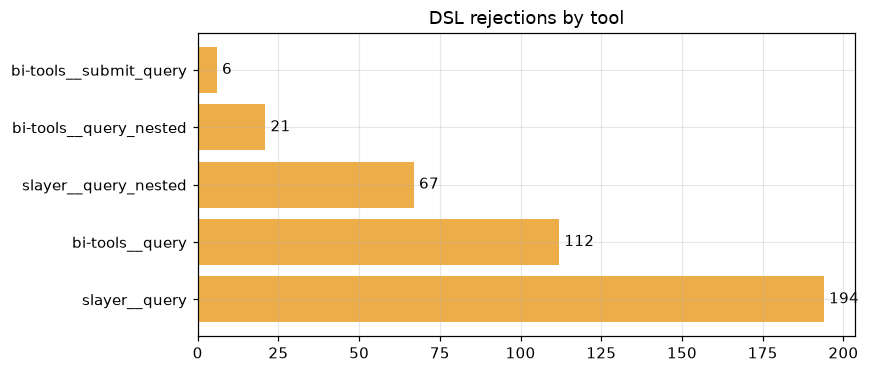

,dsl_rejections
tool,
mcp__slayer__query,194
mcp__bird-interact-tools__query,112
mcp__slayer__query_nested,67
mcp__bird-interact-tools__query_nested,21
mcp__bird-interact-tools__submit_query,6


In [4]:
# Which tool surfaced the DSL rejections
pt = agg["per_tool_dsl"]
df_tool = pd.DataFrame({"tool": list(pt), "dsl_rejections": list(pt.values())})
fig, ax = plt.subplots(figsize=(8, 3.5))
short = [t.replace("mcp__", "").replace("bird-interact-tools", "bi-tools")
         for t in df_tool["tool"]]
ax.barh(short, df_tool["dsl_rejections"], color="#edae49")
for y, v in enumerate(df_tool["dsl_rejections"]):
    ax.text(v, y, f" {v}", va="center")
ax.set_title("DSL rejections by tool")
plt.tight_layout()
plt.show()
df_tool.set_index("tool")

### Detailed breakdown of the other failure modes

`order_shape` is a single mechanical slip; the **rest of the long tail is more
interesting** because each one is a distinct SLayer-DSL idiom the agent has to
learn. Below: every DSL failure mode *except* `order_shape`, with a one-line
description and real example error text sampled from the trajectories.

In [5]:
sub = agg["dsl_subtag_counts"]
total_dsl = sum(sub.values())
rows = [{"sub_tag": t, "count": c,
         "share_%": round(100 * c / total_dsl, 1),
         "what went wrong": aqsr.SUBTAG_DESCRIPTIONS.get(t, "")}
        for t, c in sub.items() if t != "order_shape"]
df_other = pd.DataFrame(rows).set_index("sub_tag")
non_order = total_dsl - sub.get("order_shape", 0)
print(f"{non_order} of {total_dsl} DSL rejections ({100*non_order/total_dsl:.0f}%) "
      f"are NON-order_shape, across {len(rows)} distinct modes")
df_other

217 of 400 DSL rejections (54%) are NON-order_shape, across 14 distinct modes


,count,share_%,what went wrong
sub_tag,,,
filter_construction,56,14.0,A `filters` entry SLayer can't build: referenc...
aggregation_rule,44,11.0,An aggregation that isn't allowed for the colu...
unknown_transform,27,6.8,Referenced a transform function that doesn't e...
measure_collision,25,6.2,Two measures in the query canonicalise to the ...
column_not_found,14,3.5,Referenced a column/field that the named model...
top_level_shape,13,3.2,The top-level query JSON is the wrong shape: m...
formula_syntax,12,3.0,A `measures` formula that won't parse — invali...
no_join_path,8,2.0,The query crosses two models with no declared ...
transform_usage,5,1.2,A transform used incorrectly — e.g. a `partiti...


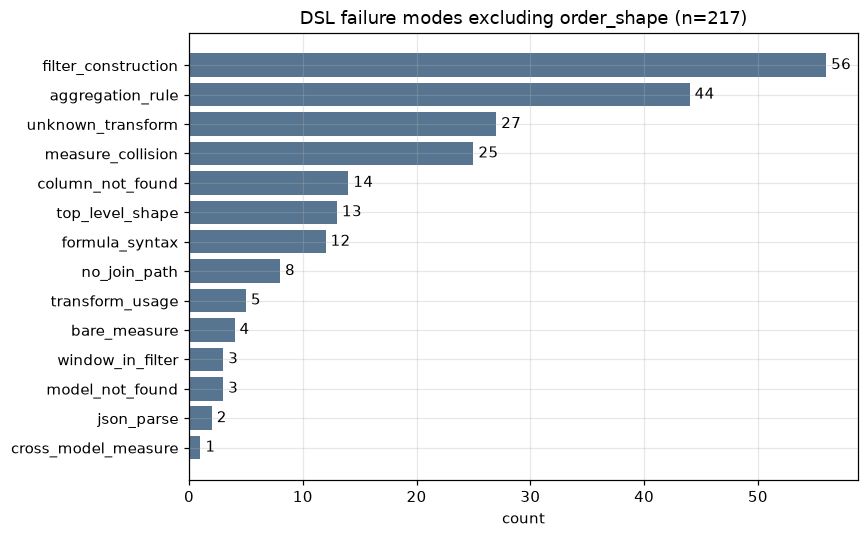

In [6]:
# Share of the non-order_shape rejections only (zoom into the tail)
tail = [(t, c) for t, c in sub.items() if t != "order_shape"]
labels = [t for t, _ in tail][::-1]
vals = [c for _, c in tail][::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(labels, vals, color="#577590")
for y, v in enumerate(vals):
    ax.text(v, y, f" {v}", va="center")
ax.set_title(f"DSL failure modes excluding order_shape (n={sum(vals)})")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

Each mode below shows its count, what the agent got wrong, and up to a
few real example messages SLayer returned.

In [7]:
from IPython.display import Markdown, display

ex = agg["dsl_examples"]
parts = []
for tag, c in sub.items():
    if tag == "order_shape":
        continue
    parts.append(f"#### `{tag}` — {c} rejection(s) "
                 f"({100*c/total_dsl:.1f}% of all DSL)")
    parts.append(aqsr.SUBTAG_DESCRIPTIONS.get(tag, ""))
    for e in ex.get(tag, []):
        snippet = e["text"]
        snippet = (snippet[:240] + " …") if len(snippet) > 240 else snippet
        parts.append(f"- _{e['iid']}_ (`{e['tool'].replace('mcp__','')}`):  \n"
                     f"  > {snippet}")
    parts.append("")
display(Markdown("\n".join(parts)))

#### `filter_construction` — 56 rejection(s) (14.0% of all DSL)
A `filters` entry SLayer can't build: references a derived/aggregated column or an undefined name, uses an unknown filter function, or embeds a subquery (not allowed in DSL filters).
- _cold_chain_pharma_compliance_1_ (`bird-interact-tools__query`):  
  > Filter 'incidentandriskmanagement.incident_risk_record__risk__risk_level' references model 'incidentandriskmanagement' but it is not in joins for source model 'environmentalmonitoring'. Add it to source_model.joins or rewrite the filter to  …
- _credit_10_ (`slayer__query`):  
  > Error executing tool query: Filter 'bank_and_transactions.expenses_and_assets.employment_and_income.debincratio_max' references column 'debincratio_max' on 'bank_and_transactions.expenses_and_assets.employment_and_income', which doesn't res …
- _crypto_1_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Invalid filter syntax: 'marketdatanode == (select max_pk from max_node)' — invalid syntax. Perhaps you forgot a comma? (<unknown>, line 1)

#### `aggregation_rule` — 44 rejection(s) (11.0% of all DSL)
An aggregation that isn't allowed for the column/measure (e.g. `countd` on a primary key, `count_distinct` on `*`, or a non-built-in aggregation).
- _alien_2_ (`bird-interact-tools__query`):  
  > Aggregation 'stddev' is not applicable to DOUBLE column 'anomscore' in model 'signalprobabilities'. Default aggregations: ['avg', 'corr', 'count', 'count_distinct', 'covar_pop', 'covar_samp', 'first', 'last', 'max', 'median', 'min', 'percen …
- _alien_5_ (`bird-interact-tools__query`):  
  > Aggregation 'json_group' not allowed for primary-key column 'signalregistry'. Allowed: ['count', 'count_distinct']
- _cold_chain_pharma_compliance_1_ (`bird-interact-tools__query`):  
  > Aggregation 'avg' is not applicable to TEXT column 'env_metrics__temperature__excursion_duration_min' in model 'environmentalmonitoring'. Default aggregations: ['count', 'count_distinct', 'first', 'last', 'max', 'min']

#### `unknown_transform` — 27 rejection(s) (6.8% of all DSL)
Referenced a transform function that doesn't exist (e.g. `ROUND` as a transform instead of `change`/`cumsum`/`rank`/…).
- _archeology_1_ (`slayer__query`):  
  > Error executing tool query: Unknown transform function 'ROUND'. Supported: change, change_pct, consecutive_periods, cumsum, dense_rank, first, lag, last, lead, ntile, percent_rank, rank, time_shift
- _cold_chain_pharma_compliance_1_ (`bird-interact-tools__query`):  
  > Unknown transform function 'round'. Supported: change, change_pct, consecutive_periods, cumsum, dense_rank, first, lag, last, lead, ntile, percent_rank, rank, time_shift
- _cold_chain_pharma_compliance_4_ (`slayer__query`):  
  > Error executing tool query: Unknown transform function 'round'. Supported: change, change_pct, consecutive_periods, cumsum, dense_rank, first, lag, last, lead, ntile, percent_rank, rank, time_shift

#### `measure_collision` — 25 rejection(s) (6.2% of all DSL)
Two measures in the query canonicalise to the same aggregation, or a measure name shadows/collides with a source column.
- _alien_7_ (`slayer__query`):  
  > Error executing tool query: Query measure name 'aoi' collides with a source column on model 'observatories'. Pick a different name (or omit `name` to use the canonical alias). Filters and ORDER BY would otherwise bind to the source column i …
- _cold_chain_pharma_compliance_9_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Query measure name 'shipment_count' collides with a source column on model 'counts'. Pick a different name (or omit `name` to use the canonical alias). Filters and ORDER BY would otherwise bind to the sour …
- _credit_10_ (`slayer__query`):  
  > Error executing tool query: Query measure name 'delinqcount' collides with a source column on model 'credit_and_compliance'. Pick a different name (or omit `name` to use the canonical alias). Filters and ORDER BY would otherwise bind to the …

#### `column_not_found` — 14 rejection(s) (3.5% of all DSL)
Referenced a column/field that the named model doesn't expose (a SLayer-layer name resolution failure, not a DB error).
- _credit_10_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Column 'debincratio' not found in model 'raw'
- _gaming_8_ (`slayer__query`):  
  > Error executing tool query: Column 'pollratehz' not found in model 'device_perf_combined'
- _insider_7_ (`bird-interact-tools__query_nested`):  
  > Column 'patsim' not found in model 'trader'

#### `top_level_shape` — 13 rejection(s) (3.2% of all DSL)
The top-level query JSON is the wrong shape: missing `source_model`, an unsupported top-level field, an array passed to a single-stage tool, or a `queryArguments` schema-validation error.
- _archeology_1_ (`slayer__query`):  
  > Error executing tool query: 3 validation errors for queryArguments source_model.str Input should be a valid string [type=string_type, input_value={'source_name': 'scans', ...ula': 'rank(sqs:avg)'}]}, input_type=dict] For further information …
- _cold_chain_pharma_compliance_1_ (`bird-interact-tools__query`):  
  > `query_json` contains unsupported top-level field(s) ['show_sql']. The `query` preview tool accepts only these SlayerQuery fields: dimensions, distinct_dimension_values, filters, limit, measures, offset, order, source_model, time_dimensions …
- _credit_9_ (`slayer__query`):  
  > Error executing tool query: 5 validation errors for queryArguments measures.0 Input should be a valid dictionary [type=dict_type, input_value='liqassets:sum', input_type=str] For further information visit https://errors.pydantic.dev/2.12/v/ …

#### `formula_syntax` — 12 rejection(s) (3.0% of all DSL)
A `measures` formula that won't parse — invalid/unsupported formula syntax or a raw-SQL expression SLayer can't compile.
- _alien_4_ (`bird-interact-tools__query`):  
  > Invalid formula syntax: 'CAST(100.0 * *:count AS REAL) / 101.0' — invalid syntax. Perhaps you forgot a comma? (<unknown>, line 1)
- _credit_9_ (`slayer__query`):  
  > Error executing tool query: Invalid formula syntax: "CASE WHEN liqassets:sum / totassets:sum > 0.3 AND employment_and_income.mthincome:sum > 5000 THEN 'Target' ELSE 'Standard' END" — invalid syntax (<unknown>, line 1)
- _fake_1_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Invalid formula syntax: '0.4 * `securitydetection.detection_score_profile__behavior_scores__botlikscore`:avg + 0.3 * `securitydetection.detection_score_profile__behavior_scores__autobehavscore`:avg + 0.3 * …

#### `no_join_path` — 8 rejection(s) (2.0% of all DSL)
The query crosses two models with no declared join between them (`Model X has no join to Y`).
- _cross_db_2_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Model 'tiers' has no join to 'total'. Available joins: []
- _exchange_traded_funds_9_ (`bird-interact-tools__query`):  
  > Model 'funds' has no join to 'performance'. Available joins: ['exchanges', 'families', 'categories']
- _households_19_ (`slayer__query`):  
  > Error executing tool query: Model 'households' has no join to 'transportation_assets'. Available joins: ['locations', 'locations', 'service_types']

#### `transform_usage` — 5 rejection(s) (1.2% of all DSL)
A transform used incorrectly — e.g. a `partition_by`/ordering column missing for `rank`/`lag`/`dense_rank`.
- _cold_chain_pharma_compliance_9_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Field '_t0' (first) requires an unambiguous time dimension. Add a single time_dimensions entry, or set main_time_dimension to select among multiple time dimensions.
- _exchange_traded_funds_2_ (`slayer__query`):  
  > Error executing tool query: Field 'previous_year_outperformance' (lag) requires an unambiguous time dimension. Add a single time_dimensions entry, or set main_time_dimension to select among multiple time dimensions.
- _organ_transplant_2_ (`slayer__query`):  
  > Error executing tool query: Transform 'rank': partition_by column 'allocation_details.allc_region' is not a query dimension. Add it to dimensions/time_dimensions, or choose one of: allc_region, hla_mis_count, med_urgency, recip_ref_reg, tra …

#### `bare_measure` — 4 rejection(s) (1.0% of all DSL)
A bare measure name with no aggregation — needs colon syntax (e.g. `revenue:sum`, `*:count`).
- _cybermarket_9_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Bare measure name 'VTI' is not valid. Use colon syntax (e.g., 'VTI:sum', 'VTI:avg'). For COUNT(*), use '*:count'.
- _labor_certification_applications_20_ (`bird-interact-tools__query_nested`):  
  > Bare measure name 'app_count' is not valid. Use colon syntax (e.g., 'app_count:sum', 'app_count:avg'). For COUNT(*), use '*:count'.
- _mental_9_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Bare measure name 'assessmentsymptomsandrisk__assessmentbasics__patients__clinicians__facilities__resource_score_max' is not valid. Use colon syntax (e.g., 'assessmentsymptomsandrisk__assessmentbasics__pat …

#### `window_in_filter` — 3 rejection(s) (0.8% of all DSL)
A window function used inside a `filters` entry — use a rank-family transform (`rank(...) <= N`, `percent_rank(...)`) instead.
- _fake_8_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Filter references column 'irank' whose SQL contains a window function. Use a rank-family transform (e.g. `rank(<measure>) <= N`, `percent_rank(...)`, `dense_rank(...)`, `ntile(n=4, ...)`) or factor the col …
- _news_1_ (`slayer__query`):  
  > Error executing tool query: Filter references column 'global_avg_uer' whose SQL contains a window function. Use a rank-family transform (e.g. `rank(<measure>) <= N`, `percent_rank(...)`, `dense_rank(...)`, `ntile(n=4, ...)`) or factor the c …
- _organ_transplant_1_ (`slayer__query_nested`):  
  > Error executing tool query_nested: Filter references column 'match_recency_rank' whose SQL contains a window function. Use a rank-family transform (e.g. `rank(<measure>) <= N`, `percent_rank(...)`, `dense_rank(...)`, `ntile(n=4, ...)`) or f …

#### `model_not_found` — 3 rejection(s) (0.8% of all DSL)
`source_model` (or a referenced stage) names a model that doesn't exist — often a typo'd nested-stage name.
- _organ_transplant_19_ (`slayer__query`):  
  > Error executing tool query: Invalid model name '{"source_name": "compatibility_metrics", "columns": [{"name": "don_a", "sql": "hla_info.hla_a_val", "type": "DOUBLE"}, {"name": "rec_a", "sql": "recipients_immunology.hlaprofile__Hla_A_Val", " …
- _polar_5_ (`bird-interact-tools__query`):  
  > Model 'agg' not found
- _robot_7_ (`slayer__query`):  
  > Error executing tool query: Model 'robot_metrics' not found

#### `json_parse` — 2 rejection(s) (0.5% of all DSL)
The `query_json` argument was not valid JSON.
- _organ_transplant_16_ (`bird-interact-tools__query`):  
  > `query_json` could not be parsed as JSON: Expecting ',' delimiter: line 1 column 890 (char 889). Pass a SlayerQuery JSON object (the same shape `submit_query` accepts).

#### `cross_model_measure` — 1 rejection(s) (0.2% of all DSL)
A cross-model measure referenced in a context where SLayer can't resolve it.
- _crypto_4_ (`slayer__query`):  
  > Error executing tool query: Cross-model measure 'riskandmargin.risk_margin_profile__margin_thresholds__inithold' must include an aggregation (e.g., 'riskandmargin.risk_margin_profile__margin_thresholds__inithold:sum').


**Takeaways for the non-`order_shape` tail.** These cluster into a few
fixable themes:

- **Filter composition** (`filter_construction`, `window_in_filter`) — the agent
  tries to filter on a derived/aggregated value, an undefined name, a subquery,
  or a window expression. SLayer wants rank-family transforms and references to
  declared names instead.
- **Aggregation & measure idioms** (`aggregation_rule`, `bare_measure`,
  `measure_collision`, `unknown_transform`, `transform_usage`) — using an
  aggregation a column doesn't allow, forgetting the `name:agg` colon syntax,
  colliding a measure name with a source column, or misusing transforms
  (unknown function / missing time dimension).
- **Name & shape resolution** (`column_not_found`, `no_join_path`,
  `model_not_found`, `top_level_shape`) — referencing columns/models/joins that
  don't exist, or getting the top-level query JSON shape wrong.

All recover in ≤1–2 retries (see Q2), so each is a candidate for a short
prompt/docstring example rather than a behavioural fix.

## Q2 — Retries to recovery

A **chain** is a maximal run of consecutive DSL-rejected query calls for one task.
Its **length** is the number of retries the agent spent on that mistake; a chain
is **recovered** if a non-DSL query call follows it (the agent stopped repeating
the mistake), **unrecovered** if it runs to the task's last query call.

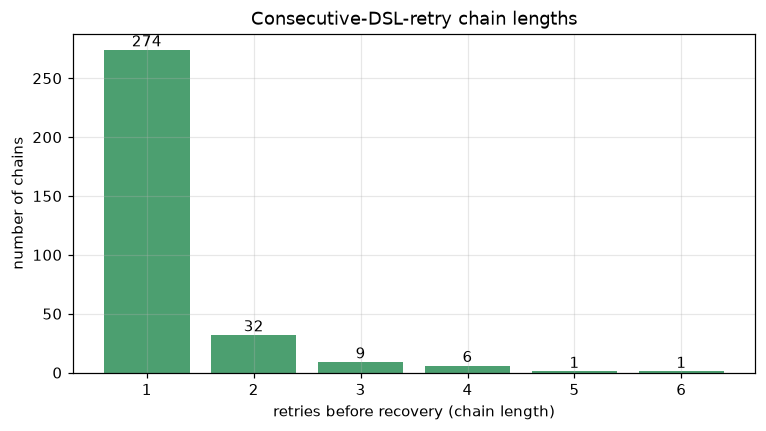

recovered chains:   322
unrecovered chains: 1
fixed on the first retry: 274/323 (85% of chains)


In [8]:
hist = {int(k): v for k, v in agg["retry_histogram"].items()}
lengths = sorted(hist)
counts = [hist[k] for k in lengths]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([str(k) for k in lengths], counts, color="#4c9f70")
for b, v in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom")
ax.set_title("Consecutive-DSL-retry chain lengths")
ax.set_xlabel("retries before recovery (chain length)")
ax.set_ylabel("number of chains")
plt.show()

total_chains = agg["chains_recovered"] + agg["chains_unrecovered"]
print(f"recovered chains:   {agg['chains_recovered']}")
print(f"unrecovered chains: {agg['chains_unrecovered']}")
if total_chains:
    p1 = 100 * hist.get(1, 0) / total_chains
    print(f"fixed on the first retry: {hist.get(1, 0)}/{total_chains} "
          f"({p1:.0f}% of chains)")

**Reading it.** The overwhelming majority of DSL mistakes are fixed on the
**very next attempt** (chain length 1), and essentially all chains recover. The
agent reads the SLayer error message and corrects in one shot — the friction is a
single wasted turn, not a spiral.

## Q3 — Was DSL syntax ever a *major contributor* to a failure?

A failed task (`phase1` did not pass) is flagged when DSL friction plausibly
*caused* the failure, via any of:

- **direct** — the *final* submission was rejected for DSL reasons
  (`submission_status in {json_error, translation_error}`);
- **never_clean** — the agent never got a single valid query through;
- **budget_burn** — the task hit budget exhaustion *and* DSL retries ate >=25% of
  the bird-coin budget.

In [9]:
fc = agg["flag_counts"]
print(f"tasks flagged major-contributor: {fc['major_contributor']} / {agg['n_failed']} failed")
print(f"  direct       = {fc['direct']}")
print(f"  never_clean  = {fc['never_clean']}")
print(f"  budget_burn  = {fc['budget_burn']}")

# Is DSL friction even correlated with failure? Compare the DSL-rejection rate
# among failed vs passed tasks.
failed = [t for t in per_task if t["failed"]]
passed = [t for t in per_task if not t["failed"]]
def rate(ts):
    return sum(1 for t in ts if t["n_dsl"] > 0) / max(len(ts), 1)
print(f"\n>=1 DSL rejection among FAILED tasks: "
      f"{sum(1 for t in failed if t['n_dsl']>0)}/{len(failed)} ({100*rate(failed):.0f}%)")
print(f">=1 DSL rejection among PASSED tasks: "
      f"{sum(1 for t in passed if t['n_dsl']>0)}/{len(passed)} ({100*rate(passed):.0f}%)")

# Budget headroom on failed tasks — how close did any failure come to exhaustion?
budgets = [(t["budget"].get("final_remaining"), t["budget"].get("total"))
           for t in failed if t["budget"].get("final_remaining") is not None]
if budgets:
    min_frac = min(r / tot for r, tot in budgets if tot)
    print(f"\nfailed tasks' budget: every one finished with budget to spare; "
          f"lowest remaining was {100*min_frac:.0f}% of the pool")

tasks flagged major-contributor: 0 / 44 failed
  direct       = 0
  never_clean  = 0
  budget_burn  = 0

>=1 DSL rejection among FAILED tasks: 39/44 (89%)
>=1 DSL rejection among PASSED tasks: 173/254 (68%)

failed tasks' budget: every one finished with budget to spare; lowest remaining was 92% of the pool


In [10]:
# Submission-status breakdown of failed tasks (why they actually failed)
from collections import Counter
status = Counter(t["submission_status"] for t in failed)
df_status = pd.DataFrame({"submission_status": list(status),
                          "failed_tasks": list(status.values())}
                        ).set_index("submission_status")
df_status

,failed_tasks
submission_status,
wrong_result,44


**Conclusion.** In these runs DSL syntax errors are **not** a major
contributor to task failure. The flags are all zero: no submission died on bad
syntax (every failure is a `wrong_result` — a *semantic* miss, the query ran but
returned the wrong rows), the agent always eventually produced a valid query, and
because these runs used a very high patience budget the cheap (<=1-coin) retries
never came close to exhausting it. DSL friction is real and pervasive
(most tasks hit at least one rejection, `order_shape` dominating), but it costs a
single corrective turn — it is a **prompt/ergonomics opportunity**, not a driver
of the 44 failures.

If a future run uses a tight budget (low `--patience`), the `budget_burn` flag is
the one to watch: re-run this notebook and check the Q3 counts.